In [1]:
# =============================================================================
# Cell 1: Environment Setup & Robust Phylogenetic Extraction
# =============================================================================
import os
import sys
import json
import time
import urllib.request
import urllib.error
import gzip
import pandas as pd
from pyspark.sql import functions as F
from pyspark.sql import SparkSession
from tqdm.auto import tqdm

# Ensure BioPython is installed for sequence parsing
try:
    from Bio import SeqIO
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "biopython"])
    from Bio import SeqIO

pd.set_option('display.max_colwidth', None)

sys.path.append('/opt/conda/lib/python3.13/site-packages')
from berdl_notebook_utils.setup_spark_session import get_spark_session
spark = get_spark_session()

print("Identifying Syntenic vs Chromosomal GT2 genes...")

target_cazy = "GT2"
window = 10000

# 1. Quick re-derivation of Syntenic vs Chromosomal GT2 genes
gene_coords = spark.table("kescience_mgnify.gene").select("genome_id", "gene_id", "contig_id", F.col("start").alias("start_pos"), F.col("end").alias("end_pos"))
eggnog = spark.table("kescience_mgnify.gene_eggnog")

t4ss_genes = eggnog.filter(F.col("eggnog_ogs").contains("COG0741") | F.lower(F.col("description")).rlike("type iv secretion|virb|t4ss|conjugal")) \
    .select("genome_id", "gene_id").join(gene_coords, on=["genome_id", "gene_id"])

cazy_genes = eggnog.filter(F.col("cazy").contains(target_cazy)) \
    .select("genome_id", "gene_id").join(gene_coords, on=["genome_id", "gene_id"])

syntenic_pairs = t4ss_genes.alias("t4").join(cazy_genes.alias("cz"), (F.col("t4.genome_id") == F.col("cz.genome_id")) & (F.col("t4.contig_id") == F.col("cz.contig_id"))) \
    .withColumn("dist", F.greatest(F.lit(0), F.greatest(F.col("t4.start_pos"), F.col("cz.start_pos")) - F.least(F.col("t4.end_pos"), F.col("cz.end_pos")))) \
    .filter(F.col("dist") <= window)

target_genomes_df = syntenic_pairs.select(F.col("cz.genome_id").alias("genome_id")).distinct()
target_genome_ids = [row.genome_id for row in target_genomes_df.collect()]

syntenic_gt2_ids = set([row.gene_id for row in syntenic_pairs.select(F.col("cz.gene_id").alias("gene_id")).distinct().collect()])
chromosomal_gt2_ids = set([row.gene_id for row in cazy_genes.filter(F.col("genome_id").isin(target_genome_ids)).select("gene_id").collect()]) - syntenic_gt2_ids

print(f"\nTargeting {len(target_genome_ids)} genomes containing {len(syntenic_gt2_ids)} syntenic and {len(chromosomal_gt2_ids)} chromosomal {target_cazy} genes.")

# --- ROBUST NETWORKING & I/O FUNCTIONS ---
def fetch_api_url_with_retry(genome_id, max_retries=4):
    api_url = f"https://www.ebi.ac.uk/metagenomics/api/v1/genomes/{genome_id}/downloads"
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
    
    for attempt in range(max_retries):
        try:
            req = urllib.request.Request(api_url, headers=headers)
            with urllib.request.urlopen(req, timeout=15) as response:
                data = json.loads(response.read().decode())
                
            for item in data.get('data', []):
                links = item.get('links', {})
                url = links.get('self') or links.get('enclosure') or links.get('url') or ""
                desc = item.get('attributes', {}).get('description', {}).get('label', '').lower()
                
                if 'cds (aa)' in desc or 'predicted cds' in desc:
                    return url
            return None
            
        except Exception as e:
            if attempt == max_retries - 1:
                return None
            time.sleep(2 ** attempt)

def download_with_retry(url, dest_path, max_retries=4):
    is_http = url.startswith('http')
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'} if is_http else {}
    
    for attempt in range(max_retries):
        try:
            if is_http:
                req = urllib.request.Request(url, headers=headers)
                with urllib.request.urlopen(req, timeout=20) as response, open(dest_path, 'wb') as out_file:
                    out_file.write(response.read())
            else:
                urllib.request.urlretrieve(url, dest_path)
            return True
        except Exception as e:
            if attempt == max_retries - 1:
                return False
            time.sleep(2 ** attempt)

def open_fasta(path):
    with open(path, 'rb') as f:
        is_gz = (f.read(2) == b'\x1f\x8b')
    return gzip.open(path, "rt") if is_gz else open(path, "rt")

# --- EXTRACTION LOOP ---
os.makedirs("data/phylogeny/raw_faa", exist_ok=True)
extracted_records = []

print("\nStarting self-healing download and parsing process...")

success_count = 0
missing_count = 0
parse_errors = 0

for i, genome_id in enumerate(tqdm(target_genome_ids, desc="Processing Genomes")):
    out_gz = f"data/phylogeny/raw_faa/{genome_id}.faa.gz"
    
    # SELF-HEALING FIX: Ensure file exists AND is larger than 500 bytes (protects against empty/broken files)
    if not (os.path.exists(out_gz) and os.path.getsize(out_gz) > 500):
        faa_url = fetch_api_url_with_retry(genome_id)
        if faa_url:
            success = download_with_retry(faa_url, out_gz)
            if not success:
                missing_count += 1
                continue
        else:
            missing_count += 1
            continue

    # B. PARSING
    try:
        found_syntenic = 0
        found_chromosomal = 0
        
        with open_fasta(out_gz) as handle:
            for record in SeqIO.parse(handle, "fasta"):
                if record.id in syntenic_gt2_ids:
                    record.id = f"SYNTENIC_{record.id}"
                    record.description = ""
                    extracted_records.append(record)
                    found_syntenic += 1
                elif record.id in chromosomal_gt2_ids:
                    record.id = f"CHROMOSOMAL_{record.id}"
                    record.description = ""
                    extracted_records.append(record)
                    found_chromosomal += 1
                    
        success_count += 1
        
    except Exception as e:
        parse_errors += 1

output_fasta = "data/phylogeny/GT2_combined_sequences.fasta"
SeqIO.write(extracted_records, output_fasta, "fasta")

print("\n" + "="*50)
print("EXTRACTION SUMMARY:")
print("="*50)
print(f"Genomes successfully processed: {success_count}")
print(f"Genomes missing FASTA on API: {missing_count}")
print(f"Genomes with parsing errors: {parse_errors}")
print(f"Total target sequences successfully extracted: {len(extracted_records)}")
print(f"Output saved to: {output_fasta}")

/home/hmacgregor/.local/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Identifying Syntenic vs Chromosomal GT2 genes...

Targeting 1096 genomes containing 1185 syntenic and 7060 chromosomal GT2 genes.

Starting self-healing download and parsing process...


Processing Genomes: 100%|██████████| 1096/1096 [00:06<00:00, 169.55it/s]


EXTRACTION SUMMARY:
Genomes successfully processed: 1096
Genomes missing FASTA on API: 0
Genomes with parsing errors: 0
Total target sequences successfully extracted: 8245
Output saved to: data/phylogeny/GT2_combined_sequences.fasta


In [2]:
# =============================================================================
# Cell 2: MAFFT & FastTree Execution
# =============================================================================
import os
import sys
import subprocess

print("Installing MAFFT and FastTree via Conda into the active Python environment...")

# 1. Install via conda using subprocess (ensures it targets your exact environment)
try:
    subprocess.run(["conda", "install", "-y", "-c", "bioconda", "mafft", "fasttree"], check=True)
except Exception as e:
    print(f"Conda installation encountered an issue: {e}")

# 2. Construct the absolute paths to the installed binaries
bin_dir = os.path.join(sys.prefix, "bin")
mafft_path = os.path.join(bin_dir, "mafft")
fasttree_path = os.path.join(bin_dir, "FastTree")

input_fasta = "data/phylogeny/GT2_combined_sequences.fasta"
aligned_fasta = "data/phylogeny/GT2_aligned.fasta"
output_tree = "data/phylogeny/GT2_gene_tree.nwk"

# Verify they actually exist before running
if not os.path.exists(mafft_path):
    print(f"Error: MAFFT binary not found at {mafft_path}.")
    print("Your environment might restrict conda installs. Try running '!conda install -y -c bioconda mafft' in a cell directly.")
else:
    print(f"\nTools found at {bin_dir}! Starting alignment...")
    
    # 3. Run MAFFT Alignment
    try:
        with open(aligned_fasta, "w") as out_file:
            # MAFFT writes its output to stdout, so we redirect it to our file
            subprocess.run([mafft_path, "--auto", input_fasta], stdout=out_file, stderr=subprocess.PIPE, check=True)
        print(f"Alignment complete! Saved to {aligned_fasta}")
    except subprocess.CalledProcessError as e:
        print(f"MAFFT failed: {e.stderr.decode()}")

    # 4. Run FastTree
    if os.path.exists(aligned_fasta):
        print("\nBuilding maximum-likelihood tree with FastTree...")
        try:
            with open(output_tree, "w") as out_tree:
                subprocess.run([fasttree_path, aligned_fasta], stdout=out_tree, stderr=subprocess.PIPE, check=True)
            print(f"Tree building complete! Saved to {output_tree}")
            print("\nYou can now download the .nwk file and upload it to https://itol.embl.de/ for visual reconciliation!")
        except subprocess.CalledProcessError as e:
            print(f"FastTree failed: {e.stderr.decode()}")

Installing MAFFT and FastTree via Conda into the active Python environment...
Conda installation encountered an issue: Command '['conda', 'install', '-y', '-c', 'bioconda', 'mafft', 'fasttree']' returned non-zero exit status 1.

Tools found at /home/hmacgregor/.local/envs/bio_env/bin! Starting alignment...
Alignment complete! Saved to data/phylogeny/GT2_aligned.fasta

Building maximum-likelihood tree with FastTree...
Tree building complete! Saved to data/phylogeny/GT2_gene_tree.nwk

You can now download the .nwk file and upload it to https://itol.embl.de/ for visual reconciliation!


Loading and formatting the phylogenetic tree...
Drawing tree (this may take a few seconds for large trees)...


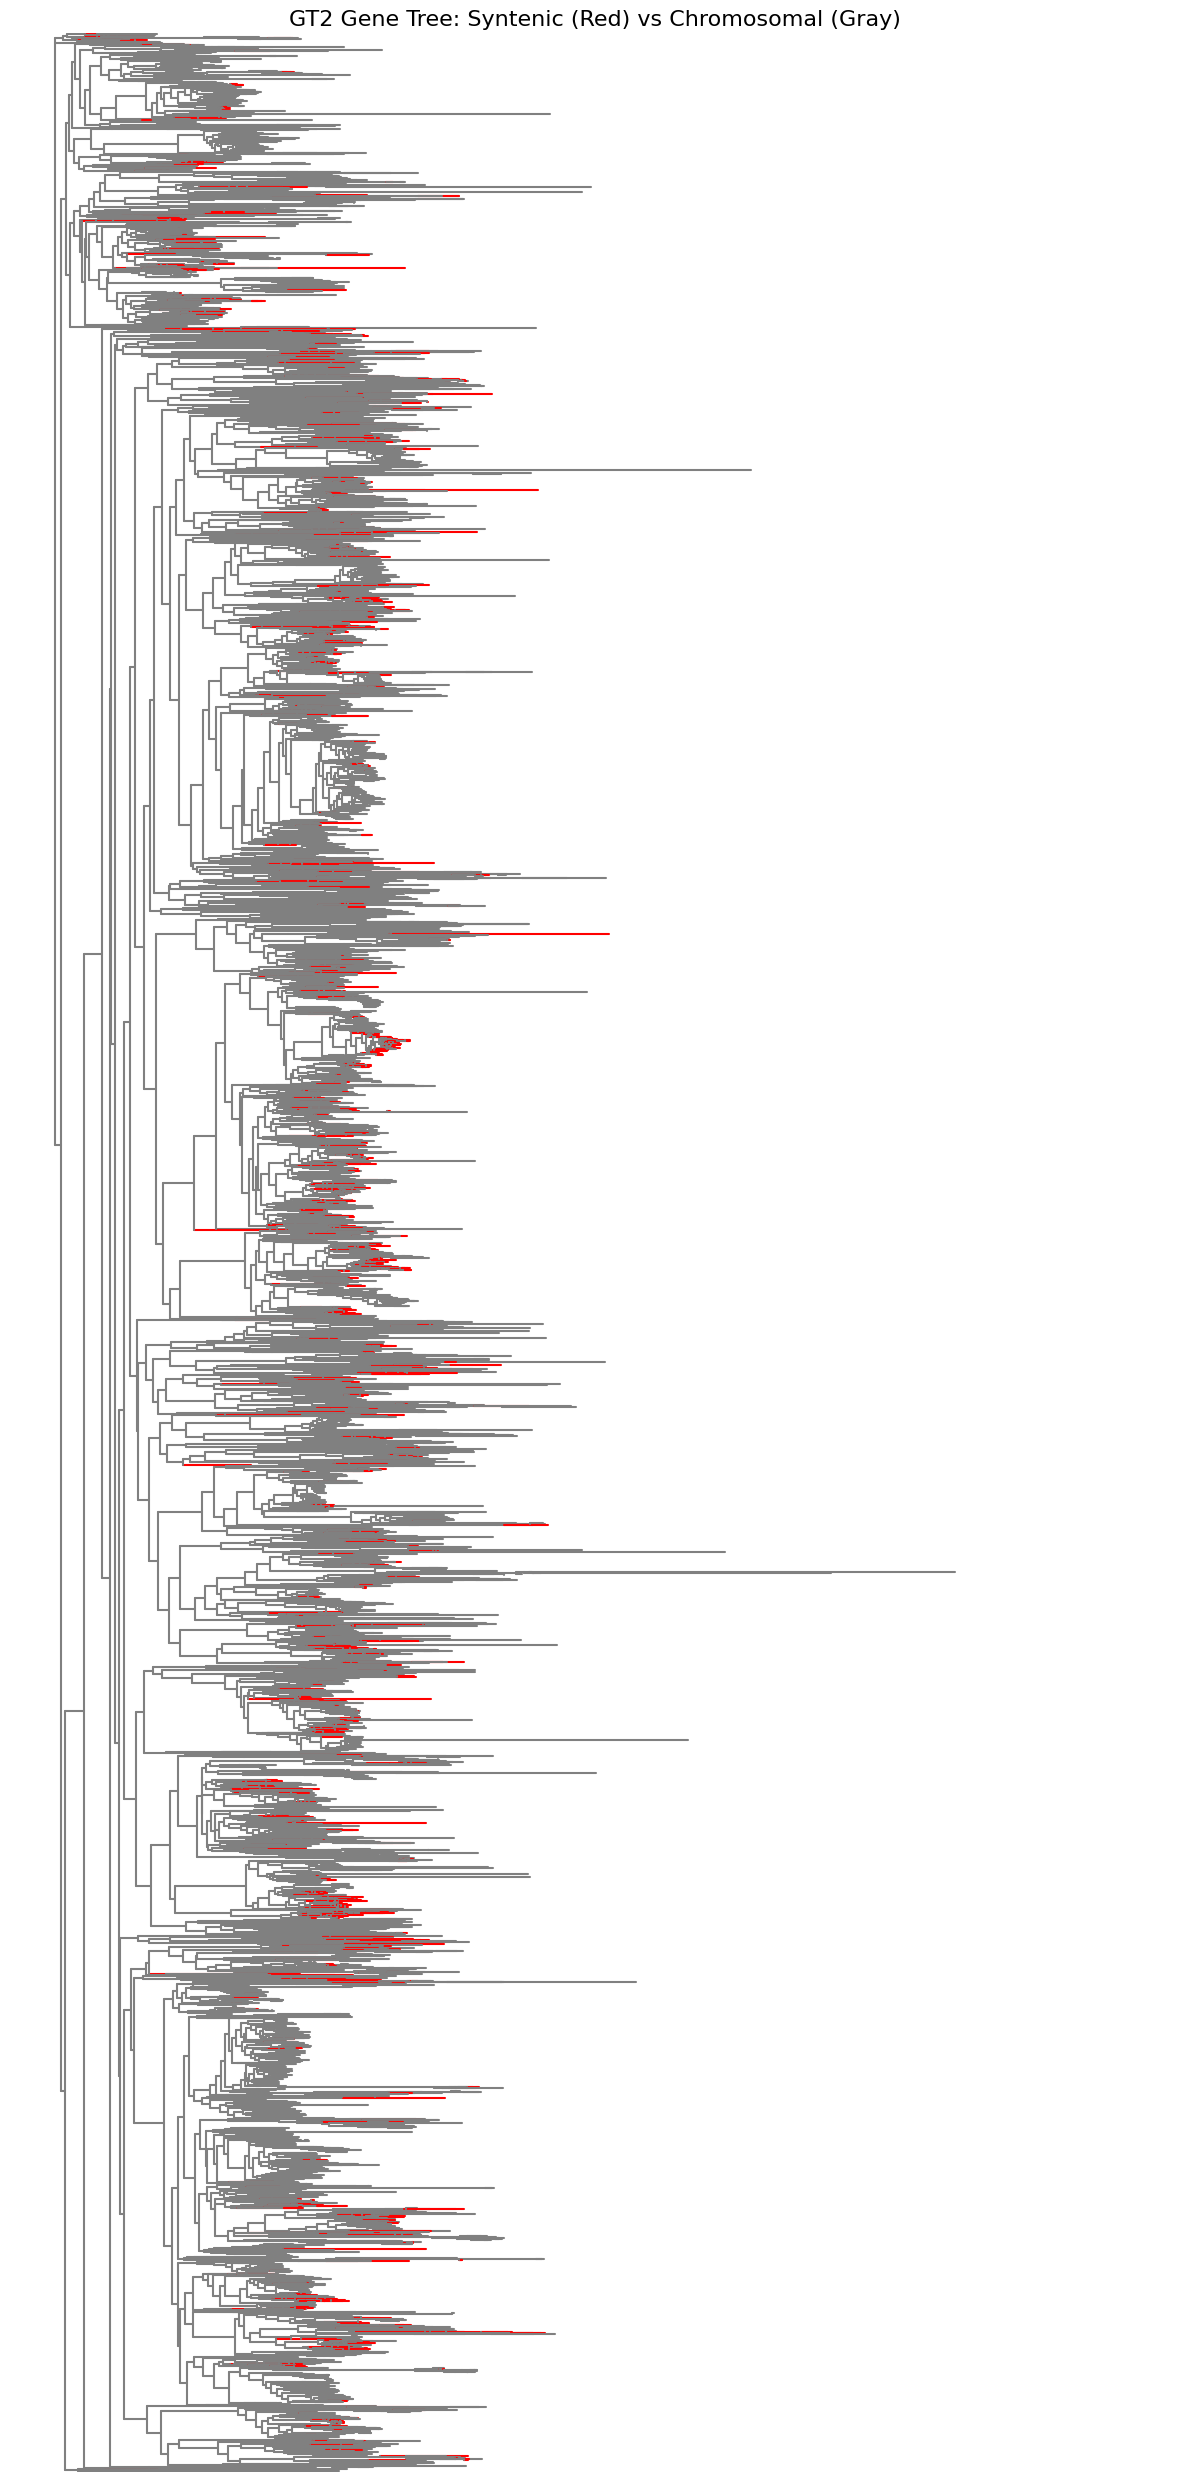

In [3]:
# =============================================================================
# Cell 3: Visualize Phylogenetic Tree in Python (Macro-View)
# =============================================================================
import matplotlib.pyplot as plt
from Bio import Phylo

tree_path = "data/phylogeny/GT2_gene_tree.nwk"

print("Loading and formatting the phylogenetic tree...")

try:
    # 1. Load the Newick tree
    tree = Phylo.read(tree_path, "newick")

    # 2. Color the branches (Red for Syntenic, Gray for Chromosomal)
    # We iterate through all clades (nodes/branches) in the tree
    for clade in tree.find_clades():
        if clade.name and "SYNTENIC" in clade.name:
            clade.color = "red"
        else:
            # Default color for chromosomal/internal branches
            clade.color = "gray"

    # 3. Set up the matplotlib figure
    # Making it very tall to accommodate the thousands of leaves
    fig = plt.figure(figsize=(12, 25))
    ax = fig.add_subplot(1, 1, 1)
    
    print("Drawing tree (this may take a few seconds for large trees)...")

    # 4. Draw the tree! 
    # We use label_func=lambda x: "" to hide the thousands of text labels 
    # so we can clearly see the color clustering.
    Phylo.draw(
        tree, 
        axes=ax, 
        do_show=False, 
        label_func=lambda x: "",  # Hides text labels for a clean macro-view
        show_confidence=False
    )
    
    plt.title("GT2 Gene Tree: Syntenic (Red) vs Chromosomal (Gray)", fontsize=16)
    plt.axis("off") # Turn off the x/y axis boxes
    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(f"Error: Could not find {tree_path}. Make sure the FastTree command finished successfully.")

In [1]:
import os, time, urllib.request, json, gzip
from tqdm.auto import tqdm

# Use the discovery_mags IDs you already have in Spark
discovery_ids = [row.genome_id for row in discovery_mags.select("genome_id").distinct().collect()]

FASTA_OUT = "discovery_proteins_for_txsscan.faa"
os.makedirs("data/proteins", exist_ok=True)

def fetch_faa_url(genome_id, max_retries=4):
    """Get the CDS (aa) download URL for a genome."""
    api_url = f"https://www.ebi.ac.uk/metagenomics/api/v1/genomes/{genome_id}/downloads"
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
    for attempt in range(max_retries):
        try:
            req = urllib.request.Request(api_url, headers=headers)
            with urllib.request.urlopen(req, timeout=15) as resp:
                data = json.loads(resp.read().decode())
            for item in data.get("data", []):
                desc = item.get("attributes", {}).get("description", {}).get("label", "").lower()
                if "cds (aa)" in desc or "predicted cds" in desc:
                    return item["links"]["self"]  # return the URL string
        except Exception:
            if attempt == max_retries - 1:
                return None
            time.sleep(2 ** attempt)
    return None

def download_file(url, dest, max_retries=4):
    for attempt in range(max_retries):
        try:
            req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
            with urllib.request.urlopen(req, timeout=20) as resp, open(dest, "wb") as f:
                f.write(resp.read())
            return True
        except Exception:
            if attempt == max_retries - 1:
                return False
            time.sleep(2 ** attempt)

with open(FASTA_OUT, "w") as out_f:
    for gid in tqdm(discovery_ids, desc="Downloading and appending CDS"):
        gz_path = f"data/proteins/{gid}.faa.gz"
        # Only download if not already present
        if not os.path.exists(gz_path) or os.path.getsize(gz_path) < 500:
            url = fetch_faa_url(gid)
            if url is None:
                continue
            if not download_file(url, gz_path):
                continue
        # Append the (possibly compressed) sequences to the combined FASTA
        opener = gzip.open(gz_path, "rt") if gz_path.endswith(".gz") else open(gz_path, "rt")
        with opener as fh:
            for line in fh:
                out_f.write(line)

print(f"Protein sequences written to {FASTA_OUT}")

/home/hmacgregor/.local/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


NameError: name 'discovery_mags' is not defined